In [3]:
# 安装需要的库（第一次运行执行，后续可以注释掉）
!pip install pandas plotly shap scikit-learn matplotlib numpy

# 导包
import pandas as pd
import plotly.express as px
import shap
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier


df = pd.read_csv(r'C:\Users\xys\Downloads\emerald_data.csv')
# ==============================================================



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


,unique_id,claim,gold_label,company,justification
0,0,EVgo and Amazon partner to enable voice-initia...,not_greenwashing,EVgo / Amazon,This is a factual statement describing the new...
1,1,"Amazon's Alexa now helps EV drivers find, navi...",not_greenwashing,Amazon,This is a factual description of the new featu...
2,2,Delta reduced its onboard single-use plastic c...,not_greenwashing,Delta,"This is a specific, quantifiable achievement d..."
3,3,"Delta announces a ""zero-waste flight"" as part ...",not_greenwashing,Delta,"The ""zero-waste flight"" was a specific, one-of..."
4,4,Delta is using more fuel-efficient A321neo air...,not_greenwashing,Delta,"This is a specific, verifiable improvement in ..."


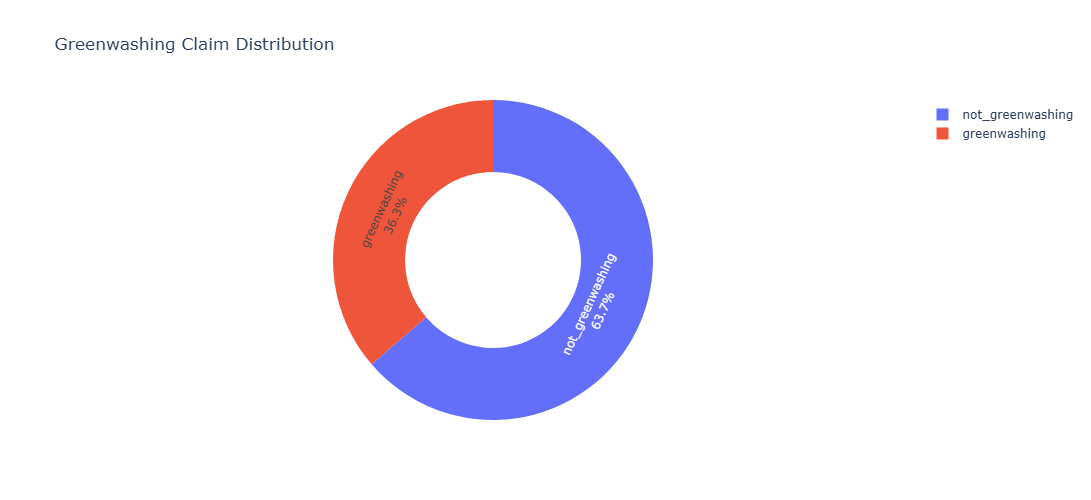

In [4]:
# Figure1 甜甜圈圆环图 标签类别分布
counts = df['gold_label'].value_counts()

fig1 = px.pie(
    values=counts.values,
    names=counts.index,
    hole=0.55,  # 圆环粗细
    title='Greenwashing Claim Distribution'
)

# 文字放在环内、显示百分比+类别名
fig1.update_traces(
    textposition='inside',
    textinfo='percent+label'
)

# IEEE海报优化：纯白背景+固定尺寸
fig1.update_layout(
    width=700,
    height=500,
    template='plotly_white'
)

fig1.show()

# 【导出高清海报图】 scale=3=3倍分辨率，存到本地
# fig1.write_image("Fig1_Donut.png", scale=3)

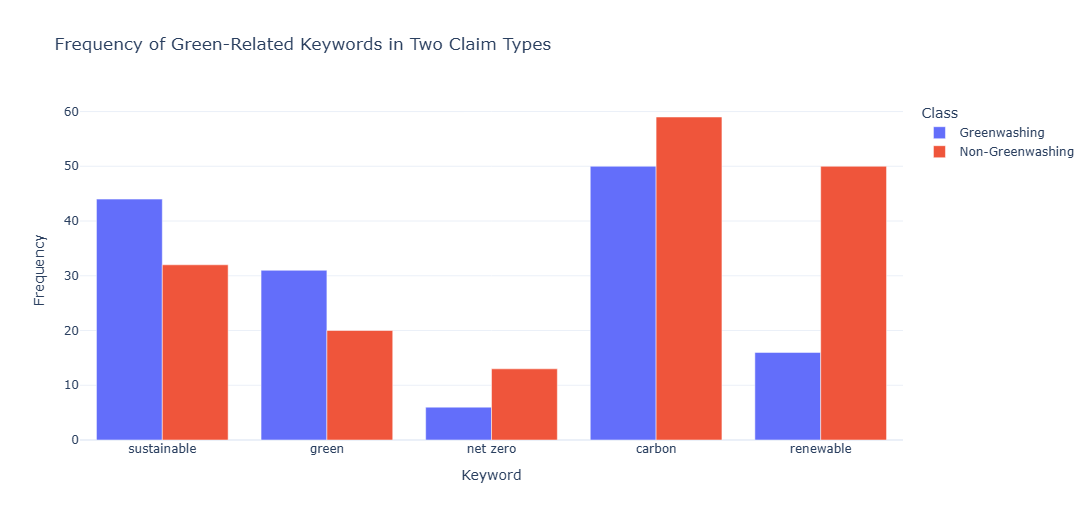

In [12]:
# Figure4 分组柱状：5个关键词在两类样本出现频次
keywords = ['sustainable', 'green', 'net zero', 'carbon', 'renewable']
save_data = []

# 循环统计每个关键词在GW/非GW里出现数量（不区分大小写匹配文本）
for kw in keywords:
    # greenwashing类包含关键词数量
    gw_num = df[(df["gold_label"]=="greenwashing") & (df["claim"].str.contains(kw, case=False, na=False))].shape[0]
    # non-greenwashing类包含关键词数量
    non_gw_num = df[(df["gold_label"]!="greenwashing") & (df["claim"].str.contains(kw, case=False, na=False))].shape[0]
    
    save_data.append({"Keyword":kw, "Frequency":gw_num, "Class":"Greenwashing"})
    save_data.append({"Keyword":kw, "Frequency":non_gw_num, "Class":"Non-Greenwashing"})

keyword_df = pd.DataFrame(save_data)

fig4 = px.bar(
    keyword_df,
    x="Keyword",
    y="Frequency",
    color="Class",
    barmode="group",  # 并列分组
    title='Frequency of Green-Related Keywords in Two Claim Types'
)

fig4.update_layout(
    width=850,
    height=520,
    template='plotly_white'
)

fig4.show()
# fig4.write_image("Fig4_GroupBar.png", scale=3)

<Figure size 800x500 with 0 Axes>

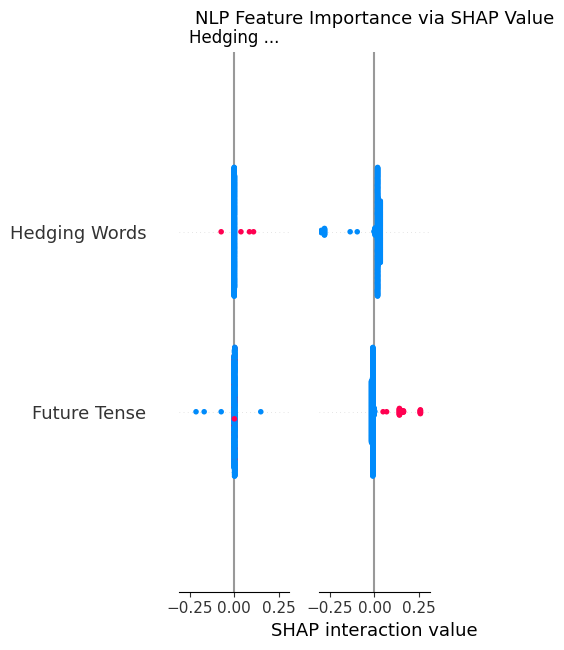

In [16]:
import re
from sklearn.ensemble import RandomForestClassifier
import shap
import matplotlib.pyplot as plt

# =========1. 关键：删除gold_label为空的样本，消除y里的NaN=========
df = df.dropna(subset=["gold_label"]).copy()

# 特征函数
def get_hedging(text):
    hedges = ['may','might','could','possibly','likely','perhaps']
    return sum(1 for w in hedges if w in str(text).lower().split())
def get_future_tense(text):
    future = ['will','shall','would','going to']
    return sum(1 for w in future if w in str(text).lower())
def get_vague_term(text):
    vague = ['some','several','many','soon','roughly','around']
    return sum(1 for w in vague if w in str(text).lower())
def get_passive(text):
    return len(re.findall(r'(was|is|are|been)\s+\w+ed',str(text).lower()))
def get_quant_data(text):
    return len(re.findall(r'\d+',str(text)))

# 生成5个特征列
df['Hedging Words'] = df['claim'].apply(get_hedging)
df['Future Tense'] = df['claim'].apply(get_future_tense)
df['Vague Terms'] = df['claim'].apply(get_vague_term)
df['Passive Voice'] = df['claim'].apply(get_passive)
df['Quantitative Data'] = df['claim'].apply(get_quant_data)

# 数据集
feat_cols = ['Hedging Words','Future Tense','Vague Terms','Passive Voice','Quantitative Data']
X = df[feat_cols].copy()
y = df['gold_label'].map({"greenwashing":1, "not_greenwashing":0})

# 再次剔除y残留空值（兜底）
valid_idx = y.notna()
X = X[valid_idx]
y = y[valid_idx]

# 训练模型
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)
explainer = shap.TreeExplainer(rf)
shap_vals = explainer.shap_values(X)

# =========2. 修复标题和图表重叠代码=========
plt.figure(figsize=(8,5))
shap.summary_plot(shap_vals, X, plot_type="bar", show=False)
plt.subplots_adjust(top=0.77)  # 顶部留白变大，数值越小留白越多
plt.title("NLP Feature Importance via SHAP Value", fontsize=13, pad=20)
plt.tight_layout()
plt.show()

# plt.savefig("Fig5_SHAP.png", dpi=300, bbox_inches="tight")

In [3]:
import pandas as pd

df = pd.read_csv(
    r"C:\Users\xys\Downloads\preprocessed_content.csv.zip",
    compression='zip'
)

print(df.columns.tolist())
print(df.head())

['Unnamed: 0', 'filename', 'ticker', 'year', 'preprocessed_content', 'ner_entities', 'e_score', 's_score', 'g_score', 'total_score']
   Unnamed: 0          filename ticker  year  \
0           0  ASX_BSX_2020.pdf    BSX  2020   
1           1  ASX_BSX_2022.pdf    BSX  2022   
2           2  ASX_EXR_2022.pdf    EXR  2022   
3           3  LSE_ADM_2019.pdf    ADM  2019   
4           4  LSE_ADM_2020.pdf    ADM  2020   

                                preprocessed_content  \
0  style guide colour colour use imagecolour prof...   
1  sustainability report look mining green office...   
2  report environment social governance esg basel...   
3  corporate social responsibilty report introduc...   
4  sustainability admiral commit maintain respons...   

                                        ner_entities  e_score  s_score  \
0  ['bk%', 'rgb', 'un', 'el ectric mine consortiu...     3.16    18.00   
1  ['murray street', 'west perth', 'west perth', ...     2.83    12.86   
2  ['september', 'm

In [5]:
import pandas as pd

df = pd.read_csv(
    r"C:\Users\xys\Downloads\preprocessed_content.csv.zip",
    compression="zip"
)

print(df.columns.tolist())

['Unnamed: 0', 'filename', 'ticker', 'year', 'preprocessed_content', 'ner_entities', 'e_score', 's_score', 'g_score', 'total_score']


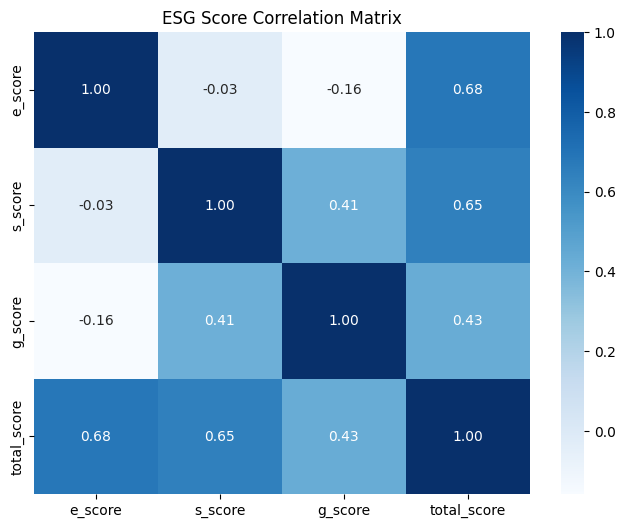

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df[['e_score','s_score','g_score','total_score']].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr,
            annot=True,
            cmap='Blues',
            fmt='.2f')

plt.title('ESG Score Correlation Matrix')
plt.show()

In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    stop_words='english',
    max_features=20
)

X = vectorizer.fit_transform(df['preprocessed_content'])

words = vectorizer.get_feature_names_out()

scores = X.sum(axis=0).A1

tfidf_df = pd.DataFrame({
    'word': words,
    'score': scores
}).sort_values(
    'score',
    ascending=False
)

print(tfidf_df.head(20))

          word       score
5     employee  293.340762
9      include  217.947531
0     business  208.001779
12     program  198.697271
14      report  182.072639
15        risk  170.768801
18        work  170.360057
2      company  168.220333
1    community  163.821967
6       energy  155.725128
16     support  153.976178
13     provide  153.045694
19        year  146.809117
11     product  144.535667
4     emission  142.438853
10  management  139.846592
3     customer  126.232209
7       global  121.582313
17       water  119.310993
8       impact  116.981395


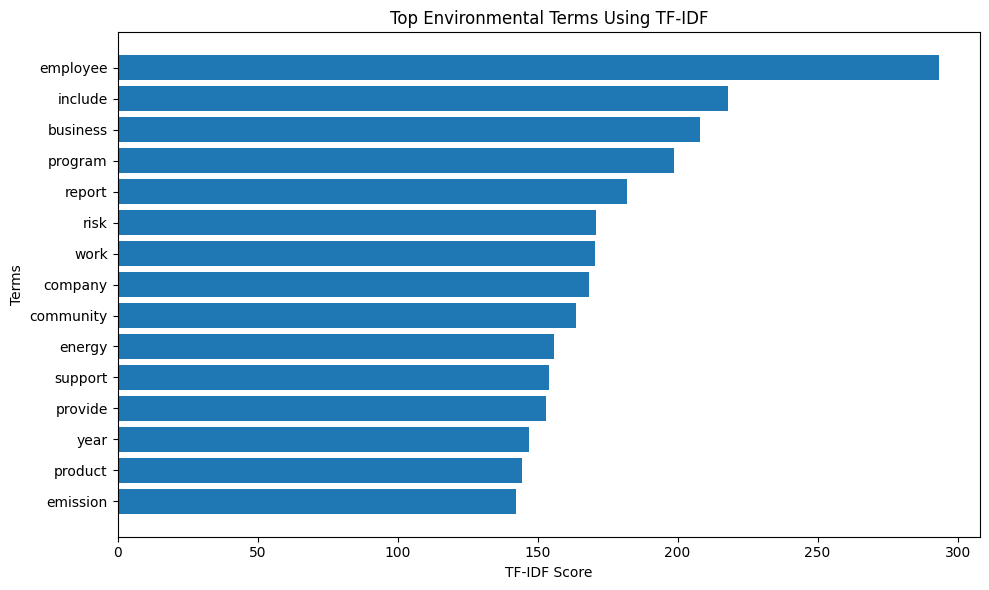

         Word  TFIDF_Score
5    employee   293.340762
9     include   217.947531
0    business   208.001779
12    program   198.697271
14     report   182.072639
15       risk   170.768801
18       work   170.360057
2     company   168.220333
1   community   163.821967
6      energy   155.725128
16    support   153.976178
13    provide   153.045694
19       year   146.809117
11    product   144.535667
4    emission   142.438853


In [11]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer

# 读取数据
df = pd.read_csv(
    r"C:\Users\xys\Downloads\preprocessed_content.csv.zip"
)

# 清理文本
df["preprocessed_content"] = (
    df["preprocessed_content"]
    .fillna("")
    .astype(str)
)

# TF-IDF
vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=20
)

X = vectorizer.fit_transform(
    df["preprocessed_content"]
)

# 获取词和权重
words = vectorizer.get_feature_names_out()
scores = X.sum(axis=0).A1

tfidf_df = pd.DataFrame({
    "Word": words,
    "TFIDF_Score": scores
})

tfidf_df = tfidf_df.sort_values(
    "TFIDF_Score",
    ascending=False
)

# 取前15个词
top_terms = tfidf_df.head(15)

# 绘图
plt.figure(figsize=(10,6))

plt.barh(
    top_terms["Word"],
    top_terms["TFIDF_Score"]
)

plt.xlabel("TF-IDF Score")
plt.ylabel("Terms")
plt.title("Top Environmental Terms Using TF-IDF")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

print(top_terms)

In [13]:
!pip install xgboost shap

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
    --------------------------------------- 1.8/101.7 MB 17.4 MB/s eta 0:00:06
   - -------------------------------------- 3.9/101.7 MB 12.5 MB/s eta 0:00:08
   -- ------------------------------------- 7.1/101.7 MB 13.2 MB/s eta 0:00:08
   --- ------------------------------------ 10.0/101.7 MB 13.3 MB/s eta 0:00:07
   ---- ----------------------------------- 12.1/101.7 MB 12.5 MB/s eta 0:00:08
   ----- ---------------------------------- 13.9/101.7 MB 11.8 MB/s eta 0:00:08
   ------ --------------------------------- 16.0/101.7 MB 11.6 MB/s eta 0:00:08
   ------- -------------------------------- 18.4/101.7 MB 11.5 MB/s eta 0:00:08
   -------- ------------------------------- 20.7/101.7 MB 11.4 MB/s eta 0:00:08
   -------- ------------------------------- 22.8/101.7 MB 11.3 MB/s eta 0:00:07
   ---------- ----------------------------- 25.4/101.7 MB 11.4 MB/s eta 0:00:07
   ----------- ---------------------------- 28.0/101


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


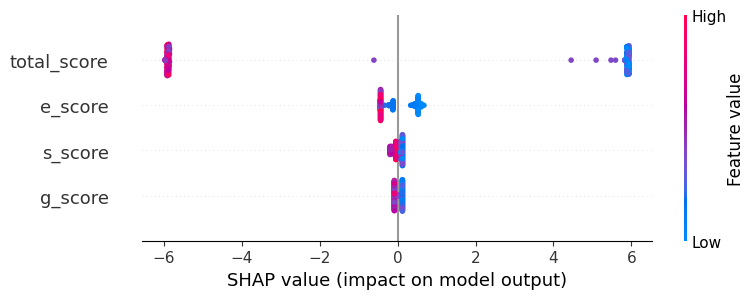

In [16]:
import pandas as pd
import xgboost as xgb
import shap
from sklearn.model_selection import train_test_split

# 读取数据
df = pd.read_csv(
    r"C:\Users\xys\Downloads\preprocessed_content.csv.zip"
)
# 构造风险标签
median_score = df["total_score"].median()

df["greenwashing_risk"] = (
    df["total_score"] < median_score
).astype(int)

# 特征
X = df[
    [
        "e_score",
        "s_score",
        "g_score",
        "total_score"
    ]
]

y = df["greenwashing_risk"]

# 划分训练集
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# XGBoost
model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    random_state=42
)

model.fit(
    X_train,
    y_train
)

# SHAP
explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(X_test)

# Summary Plot
shap.summary_plot(
    shap_values,
    X_test,
    show=True
)